In [113]:
import pandas as pd
import glob
import os
import scanpy as sc

In [114]:
from IPython.display import HTML, display
from cellphonedb.utils import db_releases_utils

display(HTML(db_releases_utils.get_remote_database_versions_html()['db_releases_html_table']))

In [3]:
sc.settings.figdir = "fig5"


In [4]:
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(20,20))


In [5]:
os.getcwd()

'/nfs/users/nfs_l/ls34/CCC_Analyses'

In [115]:
cpdb_version = 'v5.0.0'

# -- Path where the input files to generate the database are located
cpdb_target_dir = os.path.join('/nfs/team298/ls34/wound/cellphonedb/', cpdb_version)

In [116]:
from cellphonedb.utils import db_utils

db_utils.download_database(cpdb_target_dir, cpdb_version)

Downloaded cellphonedb.zip into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded complex_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded gene_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded interaction_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded protein_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded uniprot_synonyms.tsv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0/sources
Downloaded transcription_factor_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0/sources


In [8]:
0

0

In [117]:
cpdb_input_dir = '/nfs/team298/ls34/wound/cellphonedb/v5.0.0/'


In [118]:
from cellphonedb.utils import db_utils

# -- Creates new database
db_utils.create_db(cpdb_input_dir)


Created /nfs/team298/ls34/wound/cellphonedb/v5.0.0/cellphonedb_10_05_2025_132821.zip successfully


In [11]:
# %%bash

# mv /nfs/team298/ls34/cellphonedb/v5.0.0/cellphonedb_09_28_2024_123936.zip /nfs/team298/ls34/cellphonedb/v5.0.0/cellphonedb.zip

In [12]:
pd.set_option('display.max_columns', 100)

In [13]:
os.listdir(cpdb_target_dir)

['complex_input.csv',
 'cellphonedb_04_24_2025_144353.zip',
 'cellphonedb_07_13_2025_093414.zip',
 'cellphonedb_04_18_2025_084606.zip',
 'cellphonedb_07_12_2025_192405.zip',
 'cellphonedb_07_13_2025_093659.zip',
 'cellphonedb_07_12_2025_164300.zip',
 'results',
 'gene_input.csv',
 'cellphonedb_07_12_2025_165925.zip',
 'cellphonedb_04_18_2025_085909.zip',
 'cellphonedb_04_20_2025_184622.zip',
 'cellphonedb.zip',
 'cellphonedb_02_11_2025_113059.zip',
 'cellphonedb_04_22_2025_143422.zip',
 'cellphonedb_07_12_2025_165926.zip',
 'sources',
 'interaction_input.csv',
 'cellphonedb_07_13_2025_132659.zip',
 'cellphonedb_09_24_2025_092100.zip',
 'cellphonedb_02_11_2025_120244.zip',
 'cellphonedb_10_05_2025_110658.zip',
 'cellphonedb_07_12_2025_163222.zip',
 'cellphonedb_04_24_2025_100903.zip',
 'cellphonedb_04_24_2025_151255.zip',
 'cellphonedb_07_12_2025_192132.zip',
 'cellphonedb_10_03_2025_164440.zip',
 'cellphonedb_10_05_2025_105120.zip',
 'cellphonedb_04_18_2025_081529.zip',
 'cellphonedb_0

In [119]:
cpdb_file_path = os.path.join(cpdb_target_dir, 'cellphonedb.zip')
cpdb_file_path




'/nfs/team298/ls34/wound/cellphonedb/v5.0.0/cellphonedb.zip'

In [120]:
meta_file_path ='/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_all_sebo.tsv'

In [121]:
out_path = '/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore'


In [122]:
metadata = pd.read_csv(meta_file_path, sep = '\t')
metadata.head(3)

,barcode_sample,cell_type
0,GCGCGATGTGGAAAGA_GSM3717037,KC_HF_ORS0
1,CTCGTACAGCATGGCA_S4,Treg
2,CATATGGGTCCGAATT_P2,Treg


In [123]:
import anndata
#counts_file_path = '/nfs/team298/ls34/new_disease_atlas/model_scanvi5_v3skin_ADPSonly_clean_5941/ccc/normalised_log_counts_all_sebo.h5ad'
counts_file_path='/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_sebo.h5ad'
adata = anndata.read_h5ad(counts_file_path)
adata.shape

(12988, 32732)

In [124]:
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method

cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
    #active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
    #microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                       # optional: whether to score interactions or not. 
    iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
    threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
    threads = 5,                                     # number of threads to use in the analysis.
    debug_seed = 42,                                 # debug randome seed. To disable >=0.
    result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
    pvalue = 0.05,                                   # P-value threshold to employ for significance.
    subsampling = False,                             # To enable subsampling the data (geometri sketching).
    subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
    subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
    subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
    separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
    output_path = out_path,                          # Path to save results.
    output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
    )

Reading user files...
The following user files were loaded successfully:
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_sebo.h5ad
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_all_sebo.tsv
[ ][CORE][05/10/25-13:28:33][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:5 Precision:3
[ ][CORE][05/10/25-13:28:33][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][05/10/25-13:28:34][INFO] Running Real Analysis
[ ][CORE][05/10/25-13:28:34][INFO] Running Statistical Analysis


100%|██████████| 1000/1000 [03:22<00:00,  4.94it/s]


[ ][CORE][05/10/25-13:31:57][INFO] Building Pvalues result
[ ][CORE][05/10/25-13:31:59][INFO] Building results
[ ][CORE][05/10/25-13:31:59][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 23/23 [00:00<00:00, 94.47it/s]

[ ][CORE][05/10/25-13:31:59][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 23/23 [00:00<00:00, 275.69it/s]


[ ][CORE][05/10/25-13:32:00][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 529/529 [02:10<00:00,  4.06it/s]


Saved deconvoluted to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_10_05_2025_133415.txt
Saved deconvoluted_percents to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_percents_10_05_2025_133415.txt
Saved means to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_10_05_2025_133415.txt
Saved pvalues to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_10_05_2025_133415.txt
Saved significant_means to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_significant_means_10_05_2025_133415.txt
Saved interaction_scores to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_10_05_2025_133415.txt


# analysis

In [125]:
import os
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

In [127]:
try:
    decon=cpdb_results['deconvoluted']
    deconv=cpdb_results['deconvoluted']
    means = cpdb_results['means']
    pvals = cpdb_results['pvalues']
    interaction_scores=cpdb_results['interaction_scores']
    print("instantantiated")
except:
    print("not loaded")
    
    deconv = pd.read_csv("/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_percents_04_21_2025_202321.txt",  sep="\t")
    #means = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_04_21_2025_202321.txt', sep="\t")
    means = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_significant_means_04_21_2025_202321.txt', sep="\t")
    pvals = pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_04_21_2025_202321.txt", sep="\t")
    interaction_scores=pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_04_21_2025_202321.txt", sep="\t")
    import anndata
    counts_file_path = '/nfs/team298/ls34/wound/cellphonedb/input_files/normalised_log_counts.h5ad'
    adata = anndata.read_h5ad(counts_file_path)
    adata.shape
    
 # statistical_analysis_deconvoluted_percents_10_09_2024_201259.txt
#5.2M -rw-r--r-- 1 ls34 team298  21M Oct  9 20:13 
#1.8M -rw-r--r-- 1 ls34 team298  19M Oct  9 20:13 
#768K -rw-r--r-- 1 ls34 team298 5.2M Oct  9 20:13 statistical_analysis_significant_means_10_09_2024_201259.txt
 

instantantiated


In [ ]:
#genes_list = 

from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Treg',
                          'cDC2: MMP12hi',
                          'cDC2',
                          'Th',
                          'MigDC (cDC2)',
                          'Tnaive',
                          'cDC1','TRM_IL13+',
                          'Treg_LRRC32+',
                          'ILC3',
                          'cDC2: EREG+CCR7+',
                          'LC', 'ILC2', 'ILC1', 'TRM_IL17+','pDC','ILC3_CCL1+PTGDS+'],  # List of cells 1, will be paired to cells 2 (list or 'All').
    #query_cell_types_2 =  adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
     query_cell_types_2 =  ['KC_Sebocyte_DuctOuter', 'KC_Sebocyte_DuctInner', 'KC_Sebocyte_DuctInner_Junction', 'KC_HF: ORS0'],
     #    query_cell_types_2 =  ['KC2/3_cycling', 'KC_Sebocyte_duct_inner', 'cDC2',
     #                       'LC', 'cDC2: MMP12hi', 'KC_Sebocyte_duct_basal/outer',
     #                       'KCinflamm_basal', 'cDC1',
     #                       'KC_HF: ORS 1/2', 'MigDC (cDC2)', 'MigDC (cDC1)']
    #query_genes = [ "CCL19"],                                      # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 1,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)
search_results=search_results[search_results["significant_mean"]>.1]
#search_results.head(50)
search_results["interacting_pair"].unique()

array(['COL21A1_integrin_a2b1_complex', 'COL9A2_integrin_a2b1_complex',
       'CADM1_CADM1', 'CRTAM_CADM1', 'PRNP_ADGRG6', 'DSG1_DSC2',
       'CLSTN1_NRXN3', 'CLSTN3_NRXN3', 'THBS1_integrin_a3b1_complex',
       'ENTPD1_ADORA2B', 'AGRN_PTPRS', 'ANXA1_FPR1', 'ANXA1_FPR3',
       'LRPAP1_SORT1', 'Cholesterol_byLIPA_RORA',
       'Cholesterol_byDHCR24_RORA', 'Cholesterol_byDHCR7_RORA',
       'Desmosterol_byDHCR7_NR1H2', 'Dehydroepiandrosterone_bySTS_PPARA',
       'EFNB1_EPHA4', 'EFNB1_EPHB6', 'AREG_EGFR', 'EREG_EGFR',
       'HBEGF_EGFR', 'TGFA_EGFR', 'HBEGF_ERBB2', 'NCAM1_FGFR1',
       'NCAM1_AGRN', 'LGALS9_P4HB', 'HLA-E_KLRC1', 'HLA-E_CD94:NKG2A',
       'HLA-E_KLRK1', 'HLA-E_VSIR', 'HLA-F_VSIR', 'IFNG_Type_II_IFNR',
       'IL1RAP_PTPRF', 'CLEC2B_KLRF1', 'LeukotrieneB4_byLTA4H_LTB4R',
       'LeukotrieneB4_byLTA4H_LTB4R2', 'LTB_LTBR', 'TNFSF14_LTBR',
       'CD55_ADGRE5', 'DLL1_NOTCH2', 'JAG1_NOTCH2', 'JAG1_CD46',
       'OSM_OSMR', 'VEGFA_NRP2', 'ProstaglandinE2_byPTGES3_PTGER2',

In [ ]:
plot_cpdb

In [87]:
search_results[search_results["interacting_pair"] == "CCL19_CCR7"]

,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean
5377,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|LC,0.475
5643,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|MigDC (cDC2),0.997
6175,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|TRM_IL17+,0.128
6707,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|Tnaive,0.120
7771,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|cDC2,0.176
8037,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|cDC2: EREG+CCR7+,0.681
8569,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|pDC,0.881
9899,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_Sebocyte_DuctInner|LC,0.505
10165,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_Sebocyte_DuctInner|MigDC (cDC2),1.027
10697,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_Sebocyte_DuctInner|TRM_IL17+,0.157


In [58]:
GENES = [ "CCL27",

    # KC_Sebocyte_duct_inner
    "PTGS1", "SOX21", "A2ML1", "CDHR1", "SERPINB4", "LIPG", "CCDC61",

    # Sebocyte_junction
    "CDSN", "BEAN1", "KLK10", "ADGRB1", "TGM1", "SLC5A1", "OCLN", "CALB2",
    "SMPD3", "IL18", "LIPG", "NFATC2", "SH3BGRL2", "MYO5B"
        ]

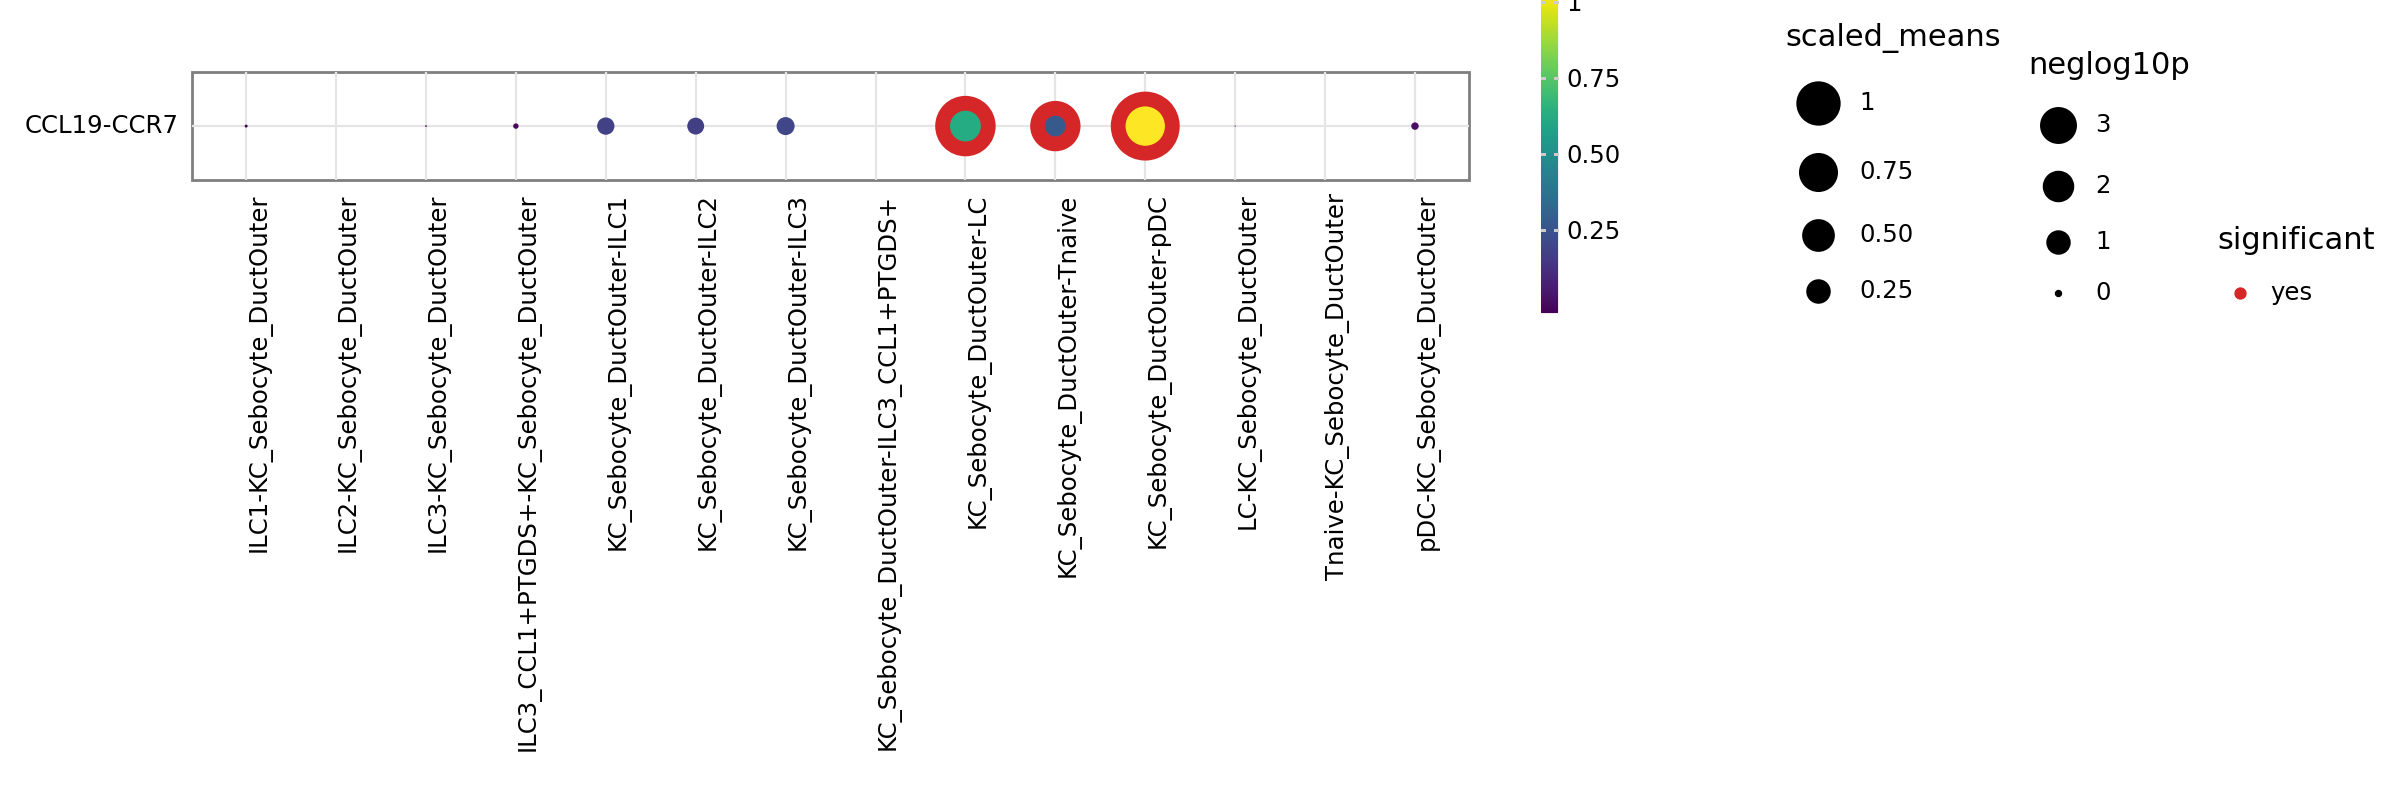

<Figure Size: (1200 x 400)>

In [106]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["LC|pDC|Tnaive"],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(12, 4),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

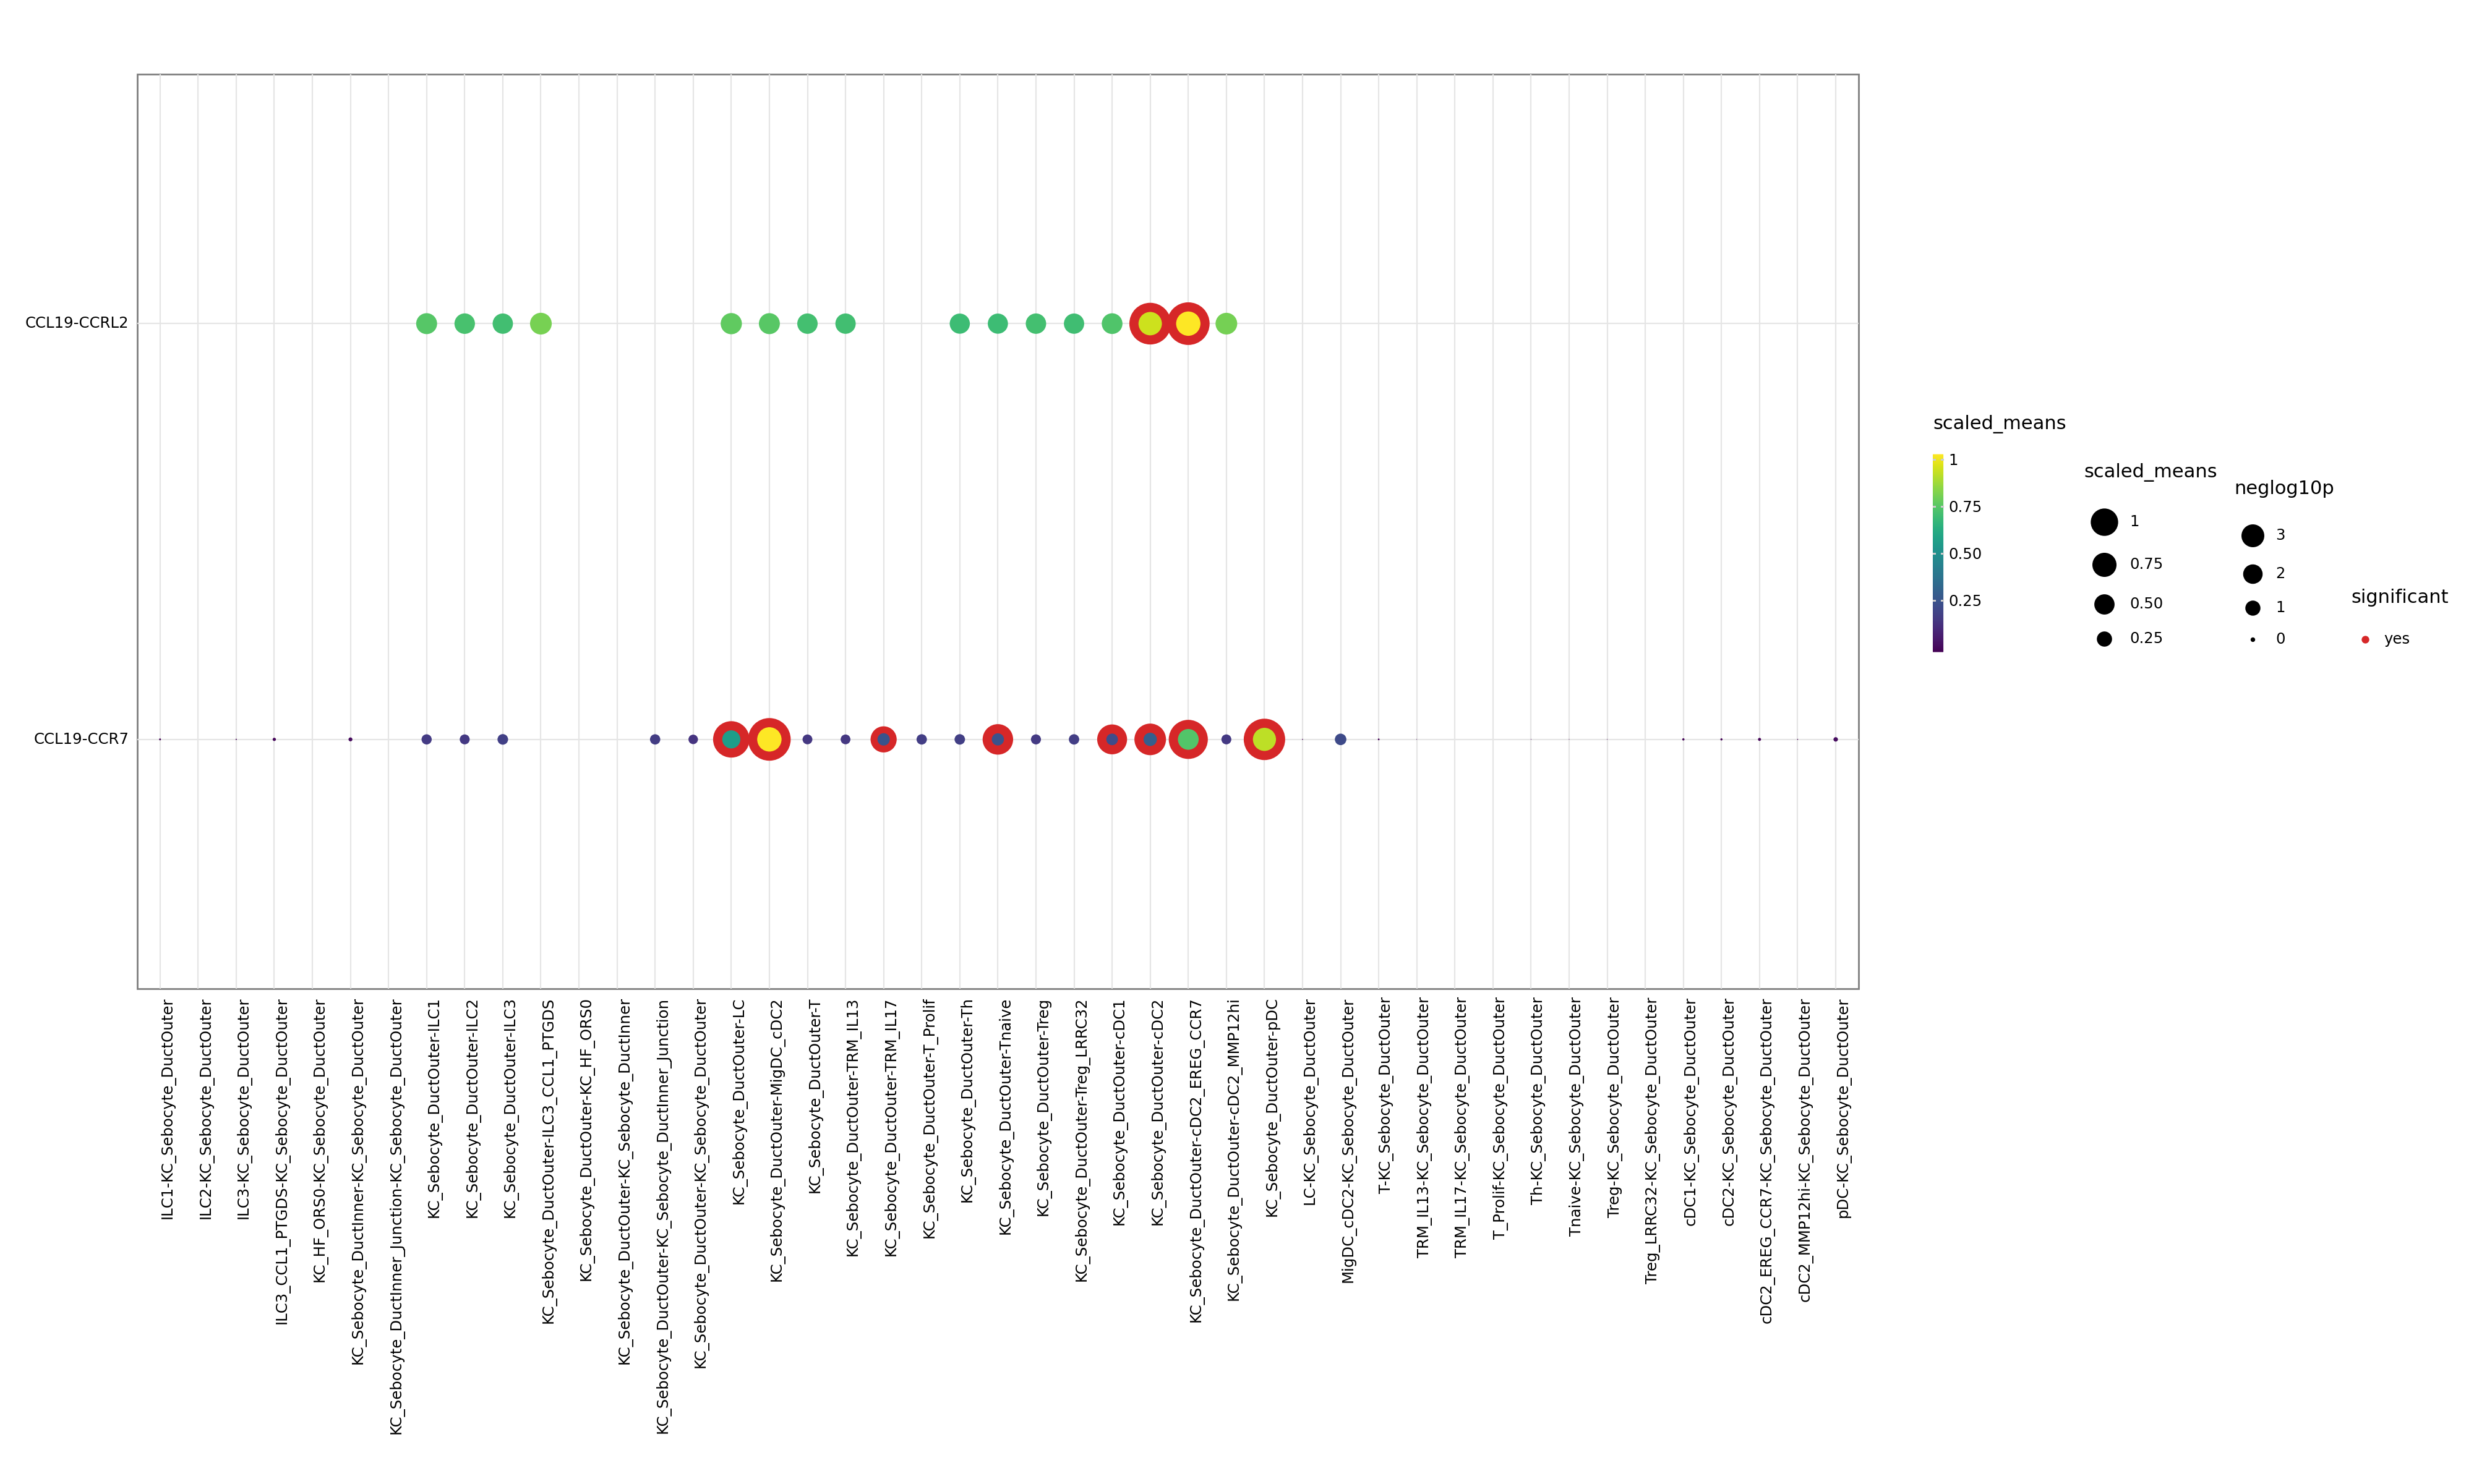

<Figure Size: (2000 x 1200)>

In [130]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["."],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(20, 12),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

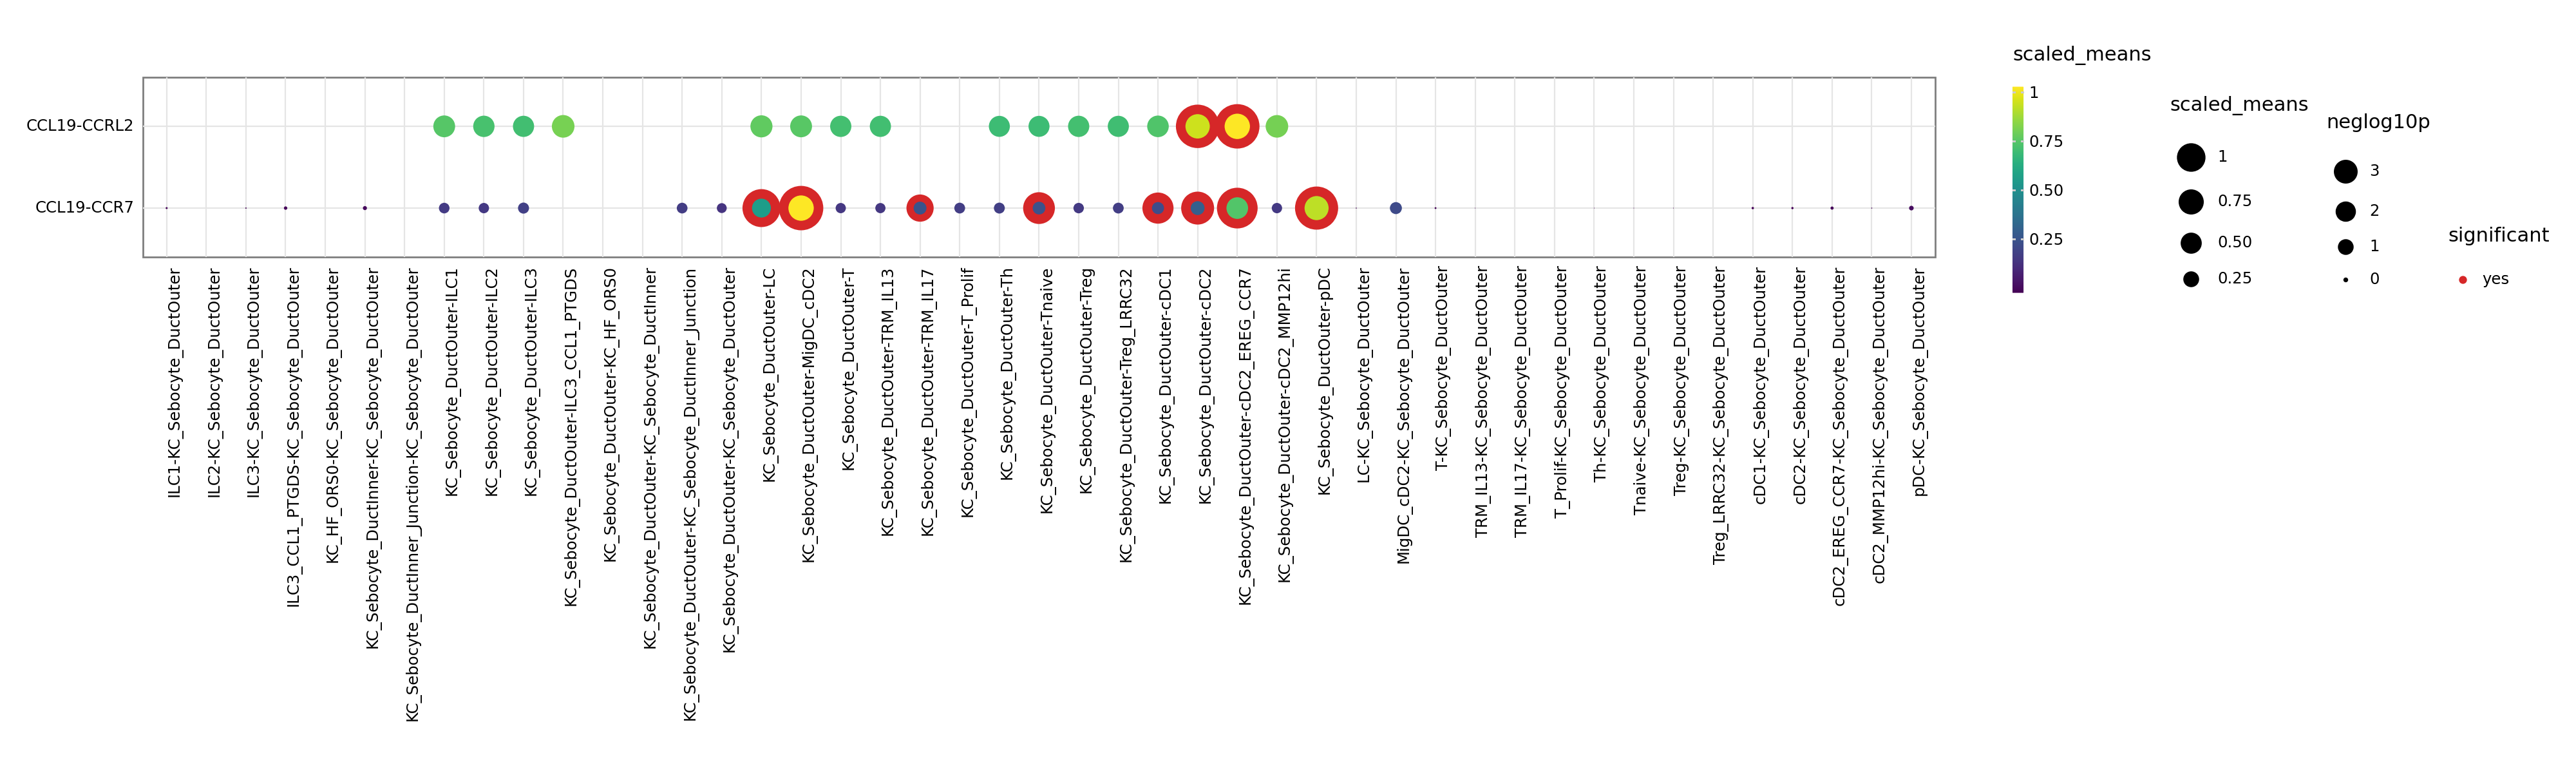

<Figure Size: (2000 x 600)>

In [135]:
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(20,20))
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["."],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(20, 6),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

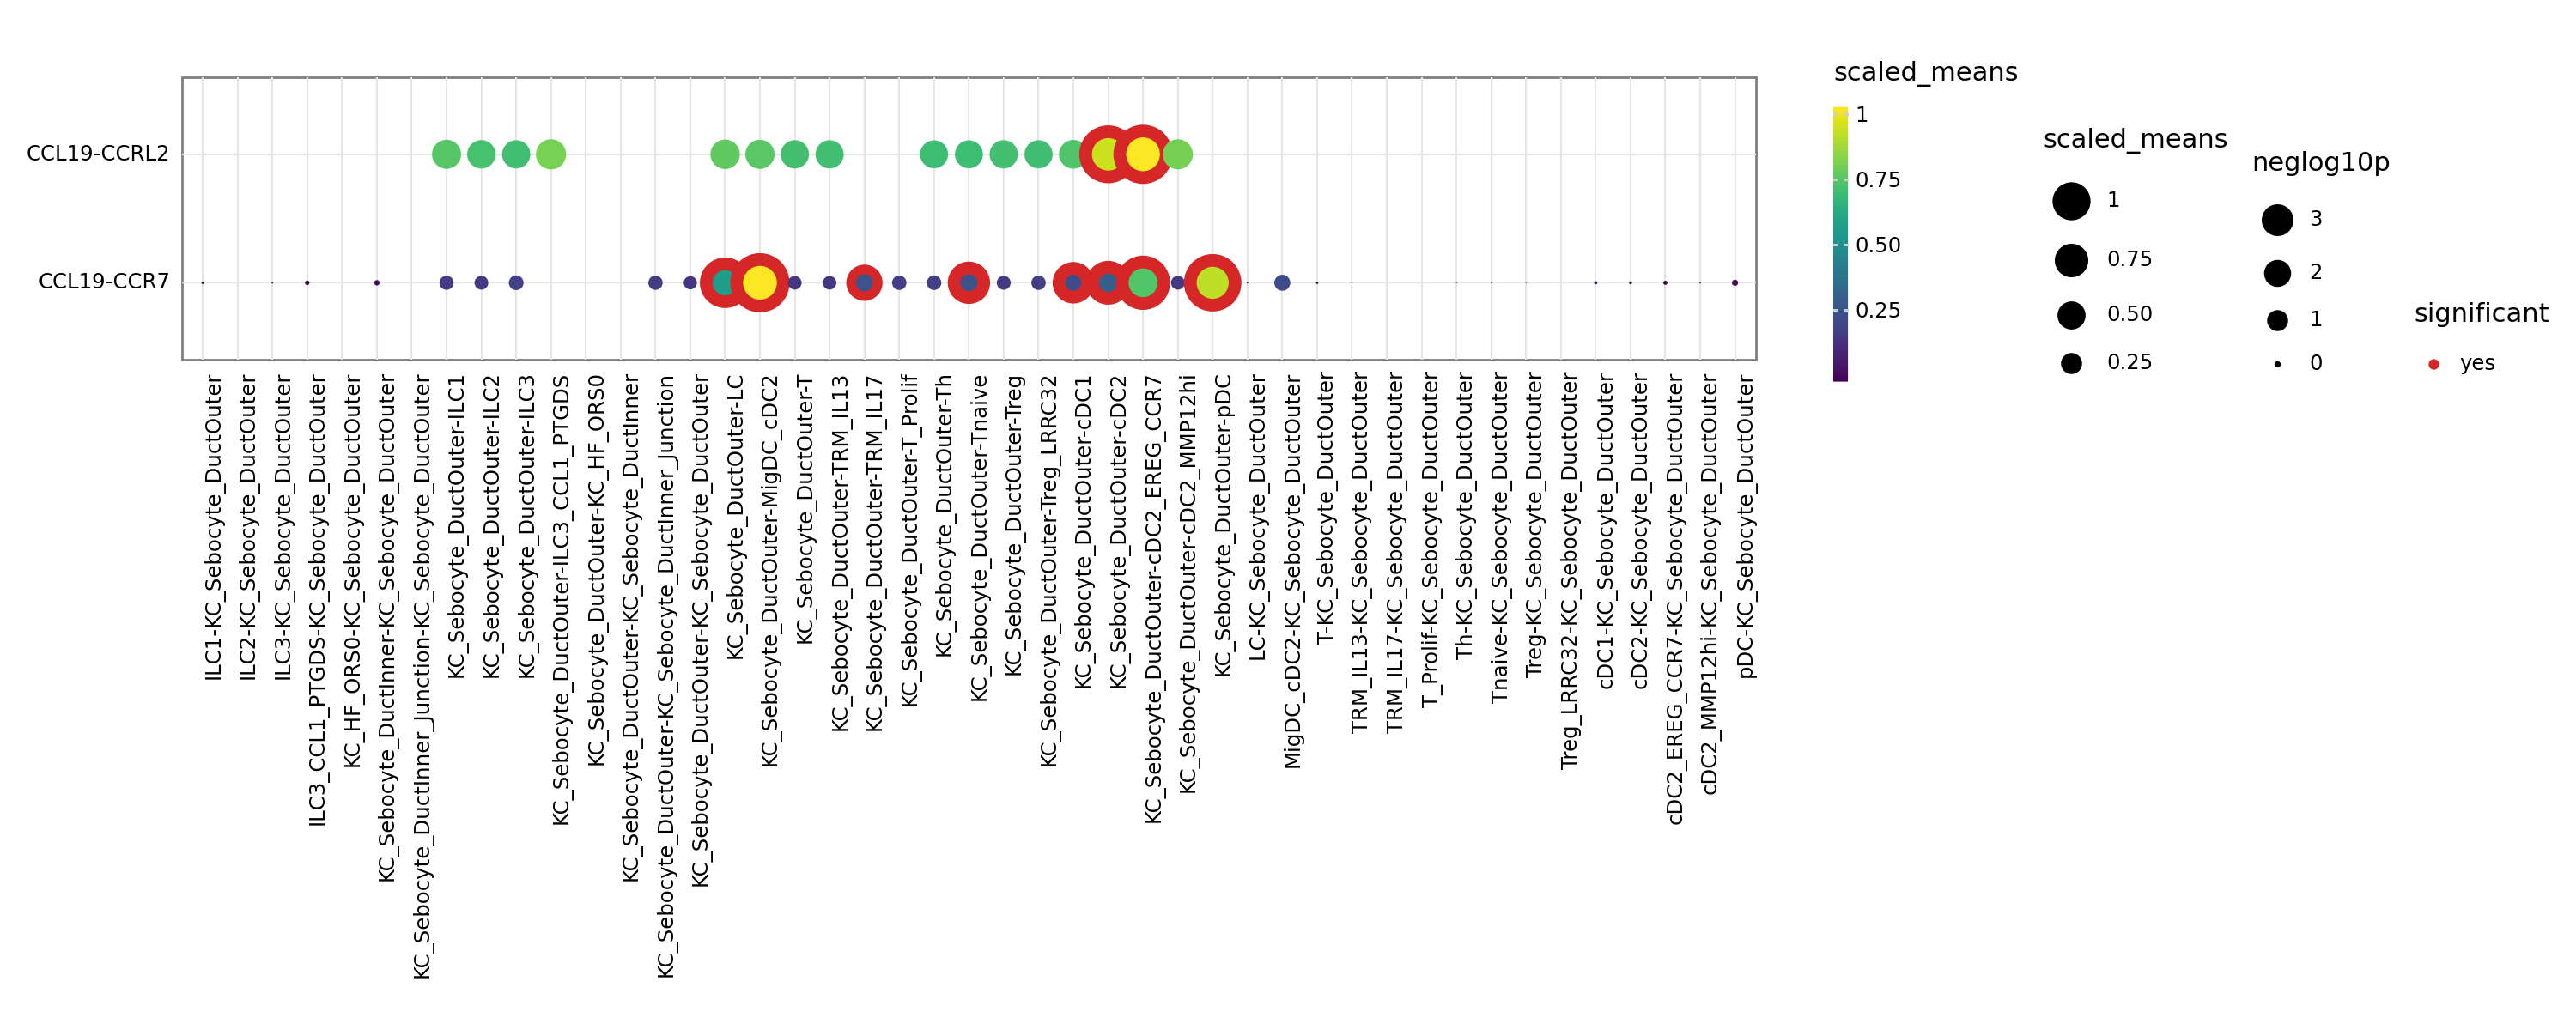

<Figure Size: (1500 x 600)>

In [136]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["."],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(15, 6),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

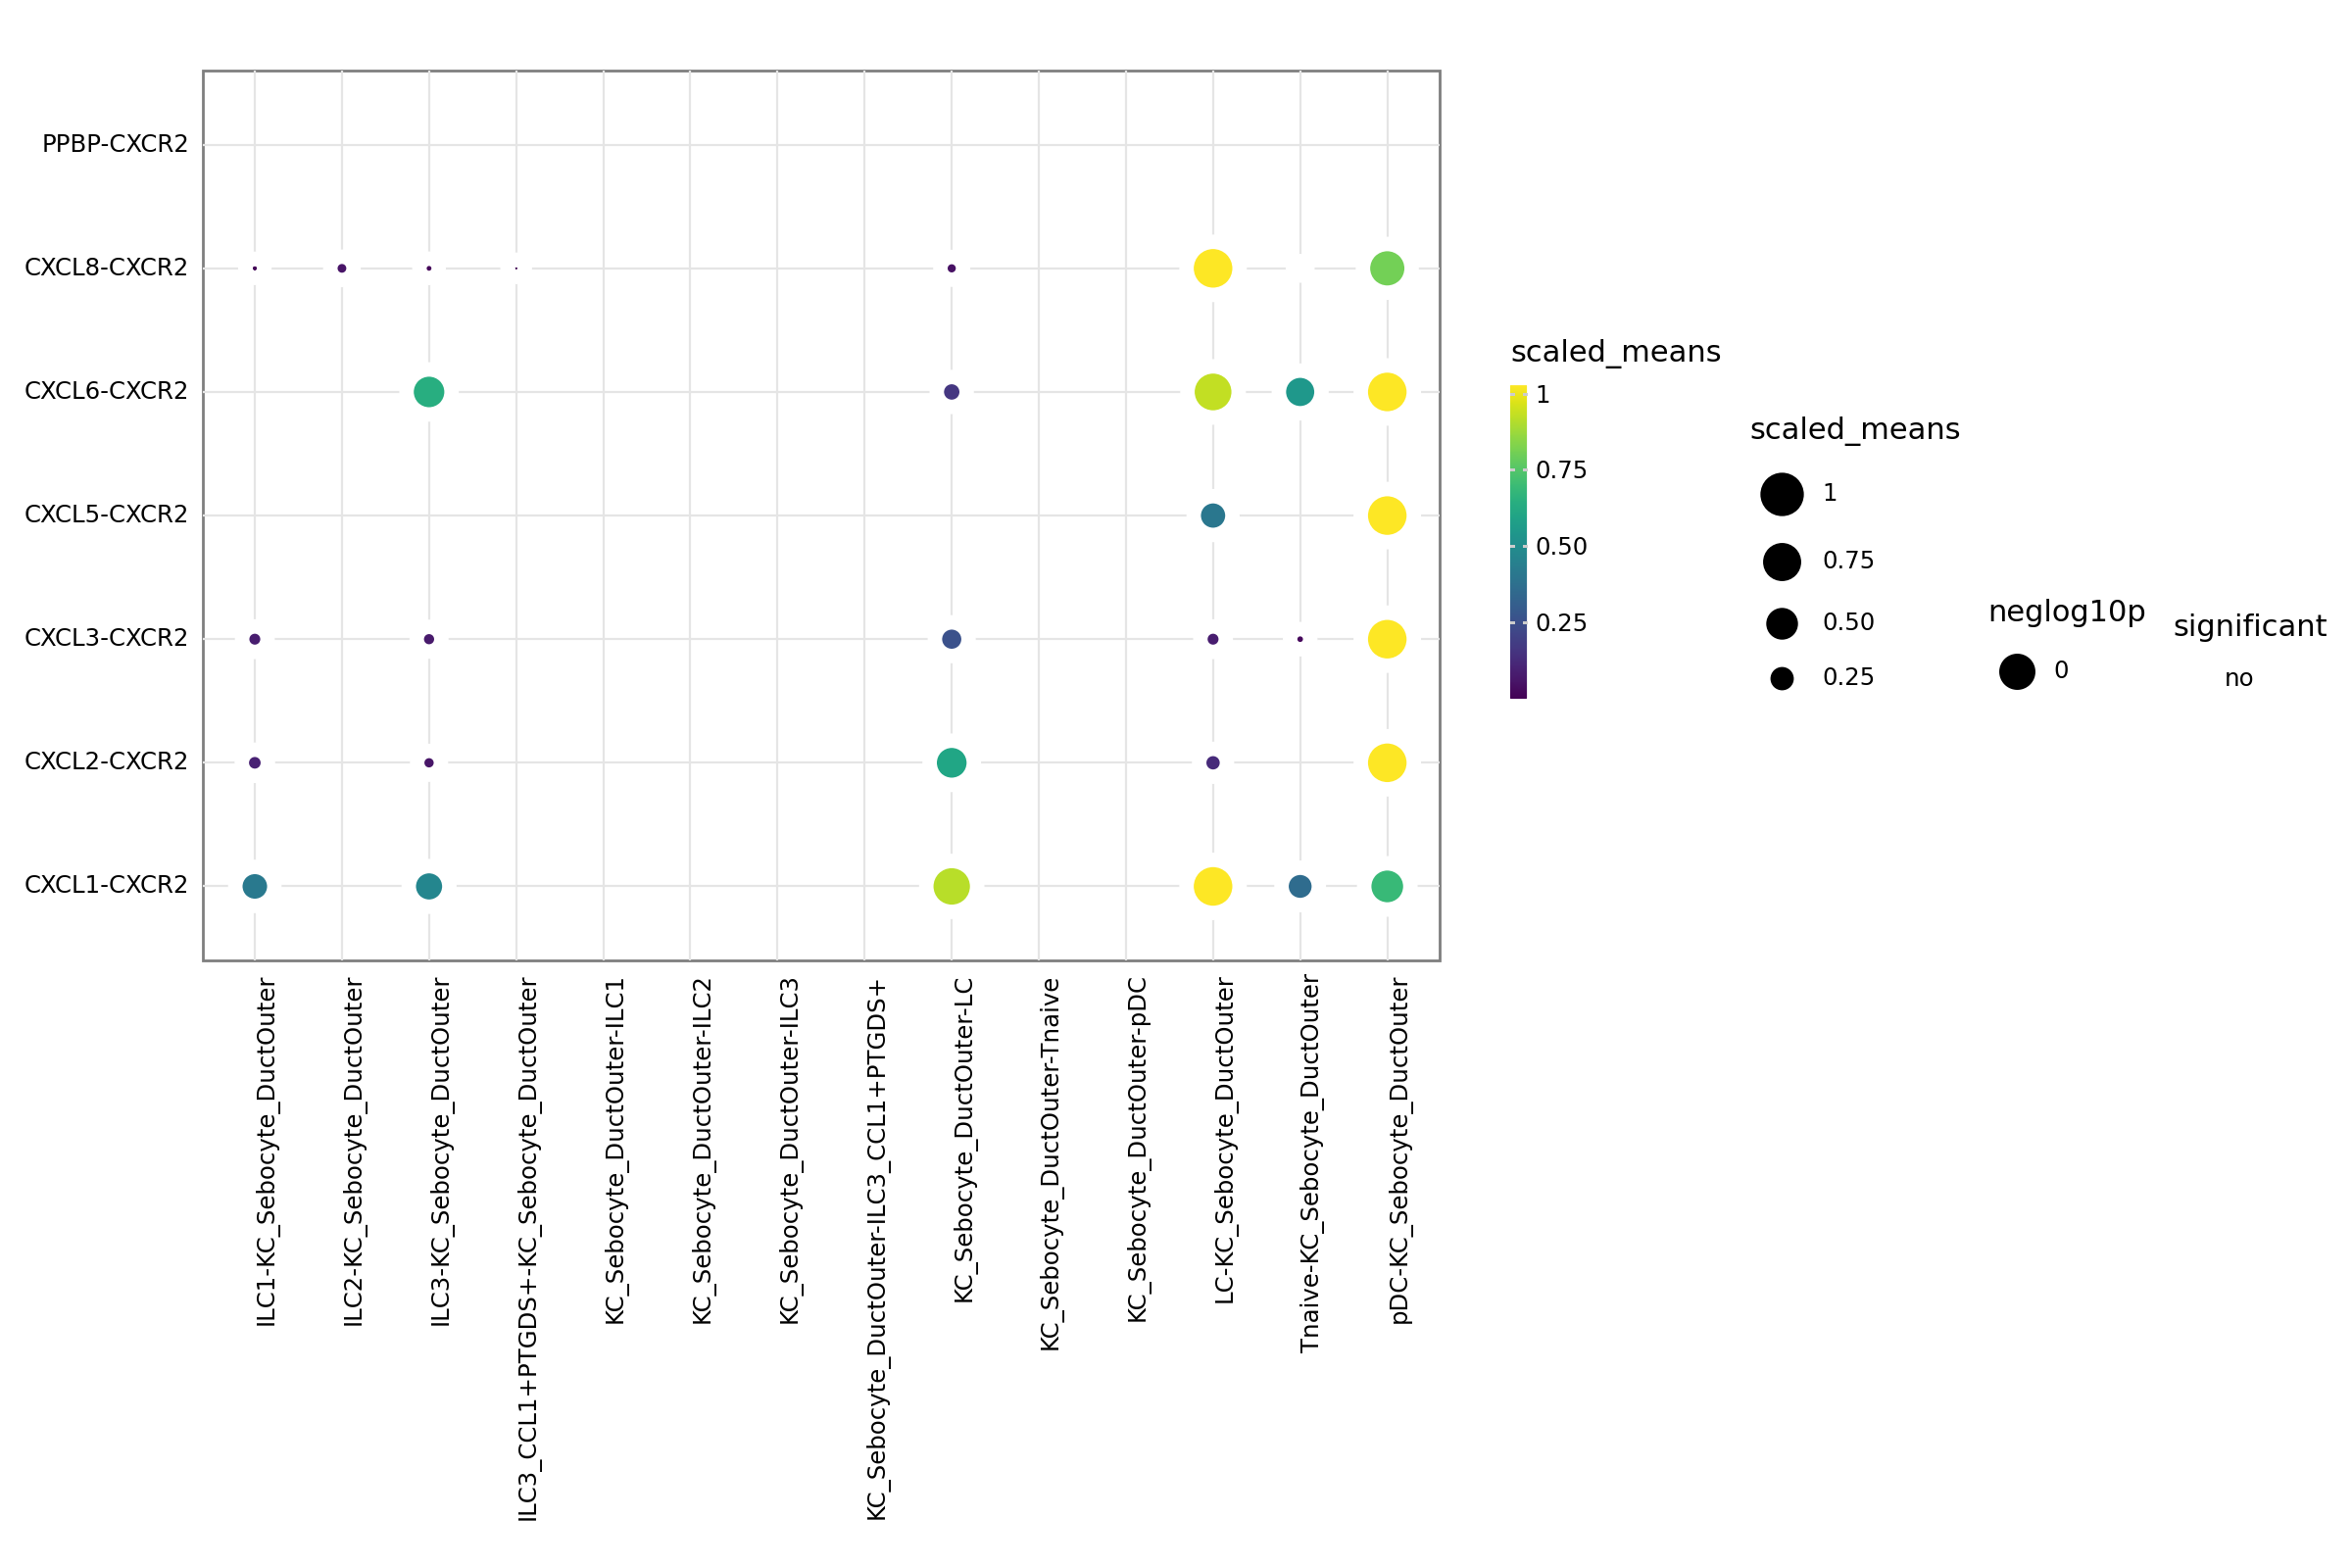

<Figure Size: (1200 x 800)>

In [108]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["LC|pDC|Tnaive"],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(12, 8),
        genes = [  "CXCR2", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  